# Comparação entre métricas normadas e a distância intrínseca no grafo de ruas

**Estudo de caso:** Ciclo Básico Unicamp → Terminal Barão Geraldo, seguido de um experimento estatístico com 10.000 pares de vértices em Campinas.

Este notebook usa o módulo `street_metrics.py`, que concentra as funções de download/carregamento do grafo, projeção métrica, cálculo de menor caminho, cálculo das métricas $L^p$, amostragem de pares, estatísticas de erro e geração de gráficos.

A ideia matemática é comparar a distância intrínseca do grafo de ruas,

$$d_G(u,v) = \min_{\gamma:u\to v}\sum_{e\in \gamma}\ell(e),$$

com distâncias induzidas por normas em $\mathbb{R}^2$:

$$d_p(x,y)=\left(|x_1-y_1|^p+|x_2-y_2|^p\right)^{1/p},$$

incluindo os casos $p=1$, $p=2$, $p=1.54$, outros valores fixos de $p$, e $p=\infty$:

$$d_\infty(x,y)=\max\{|x_1-y_1|, |x_2-y_2|\}.$$

As coordenadas são projetadas para um CRS métrico antes do cálculo das distâncias planas. Isso é essencial: latitude/longitude estão em graus, não em metros.

## 1. Instalação

In [1]:
from pathlib import Path
import sys
import math
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# O arquivo street_metrics.py deve estar no mesmo diretório deste notebook.
PROJECT_ROOT = Path.cwd()
MODULE_PATH = PROJECT_ROOT / "street_metrics.py"

if not MODULE_PATH.exists():
    raise FileNotFoundError(
        "Não encontrei street_metrics.py no diretório atual. "
        "Coloque street_metrics.py no mesmo diretório deste notebook."
    )

sys.path.insert(0, str(PROJECT_ROOT))
import street_metrics as sm

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

for folder in [DATA_DIR, FIGURES_DIR, RESULTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.precision", 4)

print("Ambiente carregado.")
print(f"Diretório do projeto: {PROJECT_ROOT}")


Ambiente carregado.
Diretório do projeto: c:\Users\caio24010\Documents\Gits\nao-e-so-reta\temp_codes_ruas


c:\Users\caio24010\Documents\Gits\nao-e-so-reta\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuração geral do experimento

O experimento tem dois níveis:

1. **Caso pontual:** Ciclo Básico Unicamp → Terminal Barão Geraldo.
2. **Caso estatístico:** 10.000 pares de vértices em Campinas.

Para rodar mais rápido durante testes, reduza `N_PAIRS` para algo como `500` ou `1000`. Depois volte para `10_000` na execução final.

In [2]:
# Lugares principais
PLACE_CASE = "Barão Geraldo, Campinas, São Paulo, Brazil"
PLACE_STATS = "Campinas, São Paulo, Brazil"

# Pontos do estudo de caso
ORIGIN_QUERY = "Rua Sérgio Buarque de Holanda, 290, Barão Geraldo, Campinas, São Paulo, Brazil"
DESTINATION_QUERY = "R. Alzira de Águiar Aranha, S/N, Jardim Santa Genebra II, Campinas, São Paulo, Brazil"

# Fallbacks.
# Formato: (latitude, longitude).
ORIGIN_FALLBACK_LATLON = (-22.817528, -47.068611)
DESTINATION_FALLBACK_LATLON = (-22.83065, -47.07957)

# Fallback aproximado para baixar um recorte de Barão Geraldo caso PLACE_CASE não resolva como polígono.
# O valor é usado somente se o download por nome falhar.
BARAO_CENTER_LATLON = (-22.8170, -47.0700)
BARAO_DIST_M = 6500

# Rede abstrata de ruas: baixamos a rede de ruas veiculares e depois ignoramos direção das vias.
NETWORK_TYPE = "drive"
MAKE_UNDIRECTED = True

# Valores fixos de p, incluindo p = 1.54.
P_VALUES = sm.DEFAULT_P_VALUES

# Experimento estatístico
N_PAIRS = 10_000
N_ORIGINS = 250
SEED = 42


## 3. Download ou carregamento do grafo de Barão Geraldo

O grafo salvo em `data/graph_barao_geraldo.graphml` é o grafo bruto do OSMnx. Sempre que ele é carregado, o módulo reprojeta o grafo para coordenadas métricas, converte para não direcionado e mantém a maior componente conexa.

Se o nome `Barão Geraldo, Campinas, São Paulo, Brazil` não resolver como polígono no Nominatim, o código tenta baixar um recorte circular com centro e raio definidos acima.


In [3]:
graph_barao_path = DATA_DIR / "graph_barao_geraldo.graphml"

try:
    G_barao = sm.load_or_download_graph(
        graph_barao_path,
        place=PLACE_CASE,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
    )
    print("Grafo de Barão Geraldo carregado por nome de lugar.")
except Exception as exc:
    print("Falha ao carregar Barão Geraldo por nome de lugar.")
    print("Erro:", repr(exc))
    print("Tentando recorte por ponto central + raio...")
    G_barao = sm.load_or_download_graph(
        graph_barao_path,
        center_point=BARAO_CENTER_LATLON,
        dist=BARAO_DIST_M,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
        force_download=True,
    )

print(f"Número de vértices: {len(G_barao.nodes):,}")
print(f"Número de arestas: {len(G_barao.edges):,}")
print("CRS:", G_barao.graph.get("crs"))

Grafo de Barão Geraldo carregado por nome de lugar.
Número de vértices: 2,186
Número de arestas: 3,276
CRS: EPSG:32723


## 4. Grafo para o experimento estatístico

Agora carregamos Campinas inteira. Dependendo da máquina e da conexão, este passo pode ser mais pesado que o recorte de Barão Geraldo.

Se quiser fazer um teste rápido só em Barão Geraldo, substitua `PLACE_STATS` por `PLACE_CASE` ou simplesmente use `G_stats = G_barao` na célula seguinte.

In [4]:
USE_CAMPINAS_FOR_STATS = False

if USE_CAMPINAS_FOR_STATS:
    graph_stats_path = DATA_DIR / "graph_campinas.graphml"
    G_stats = sm.load_or_download_graph(
        graph_stats_path,
        place=PLACE_STATS,
        network_type=NETWORK_TYPE,
        make_undirected=MAKE_UNDIRECTED,
        keep_largest_component=True,
    )
else:
    graph_stats_path = graph_barao_path
    G_stats = G_barao

print(f"Grafo estatístico: {PLACE_STATS if USE_CAMPINAS_FOR_STATS else PLACE_CASE}")
print(f"Número de vértices: {len(G_stats.nodes):,}")
print(f"Número de arestas: {len(G_stats.edges):,}")
print("CRS:", G_stats.graph.get("crs"))

Grafo estatístico: Barão Geraldo, Campinas, São Paulo, Brazil
Número de vértices: 2,186
Número de arestas: 3,276
CRS: EPSG:32723


## 5. Amostragem de 10.000 pares de vértices

A amostragem usa `N_ORIGINS` origens distintas e vários destinos por origem. Isso reduz o custo computacional, porque o menor caminho é calculado por Dijkstra uma vez por origem, não uma vez por par.

Com `N_PAIRS = 10_000` e `N_ORIGINS = 250`, serão feitas aproximadamente 250 execuções de Dijkstra.

In [5]:
pairs = sm.sample_vertex_pairs(
    G_stats,
    n_pairs=N_PAIRS,
    n_origins=N_ORIGINS,
    seed=SEED,
)

pairs_path = RESULTS_DIR / "sampled_pairs.csv"
sm.save_dataframe(pairs, pairs_path)

print(pairs.head())
print(f"Total de pares: {len(pairs):,}")
print(f"Origens distintas: {pairs['origin'].nunique():,}")
print("Pares salvos em:", pairs_path)

       origin      target
0  9009327214  4297300572
1  1037596127  1040638098
2   993367297  1037621686
3  5920553995  1067977704
4  8218404531  8269957475
Total de pares: 10,000
Origens distintas: 250
Pares salvos em: c:\Users\caio24010\Documents\Gits\nao-e-so-reta\temp_codes_ruas\results\sampled_pairs.csv


## 6. Cálculo de $d_G$ e das métricas $L^p$

Esta é a etapa computacional central. O resultado está salvo em `results/results_10000_pairs.csv`.

In [18]:
t0 = time.perf_counter()

results = sm.compute_pair_metrics(
    G_stats,
    pairs,
    p_values=P_VALUES,
    show_progress=True,
)

elapsed = time.perf_counter() - t0

results_path = RESULTS_DIR / "results_10000_pairs.csv"
sm.save_dataframe(results, results_path)

print(f"Cálculo concluído em {elapsed/60:.2f} minutos.")
print(f"Resultados salvos em: {results_path}")
results

Dijkstra por origem: 100%|██████████| 250/250 [00:02<00:00, 94.24it/s] 


Cálculo concluído em 0.04 minutos.
Resultados salvos em: c:\Users\caio24010\Documents\Gits\nao-e-so-reta\temp_codes_ruas\results\results_10000_pairs.csv


,origin,target,origin_x,origin_y,target_x,target_y,d_graph_m,d_L1_m,d_L1_25_m,d_L1_5_m,d_L1_54_m,d_L1_75_m,d_L2_m,d_L3_m,d_L5_m,d_L10_m,d_Linf_m,tortuosity_dG_dL2
0,9009327214,4297300572,288629.8137,7.4753e+06,286271.9303,7.4747e+06,3154.2900,2932.3719,2675.5973,2543.3304,2528.6065,2469.7457,2426.8603,2369.1968,2358.2881,2357.8835,2357.8834,1.2997
1,1037596127,1040638098,284349.7161,7.4744e+06,287604.6553,7.4718e+06,5757.3713,5860.5437,5109.7376,4665.7923,4611.2509,4374.3847,4169.3889,3736.6883,3445.3208,3288.5097,3254.9392,1.3809
2,993367297,1037621686,287651.3656,7.4760e+06,287298.1414,7.4751e+06,1953.8940,1281.4979,1144.2633,1068.3737,1059.4920,1022.5057,993.2067,945.0181,929.7501,928.2796,928.2737,1.9673
3,5920553995,1067977704,286148.1913,7.4792e+06,287222.4327,7.4781e+06,3020.8562,2114.0304,1840.4315,1678.0184,1658.0071,1570.8750,1495.0437,1332.1093,1214.8360,1134.2293,1074.2414,2.0206
4,8218404531,8269957475,286192.8211,7.4784e+06,289175.2182,7.4710e+06,8904.7588,10411.3692,9274.0789,8640.6095,8566.0884,8254.4053,8005.2682,7585.8561,7444.4012,7429.0529,7428.9722,1.1124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1040637699,1067977681,288168.8549,7.4710e+06,287187.7711,7.4775e+06,8831.5415,7402.5534,6907.6504,6674.6433,6650.2656,6557.3930,6495.9832,6429.0942,6421.5766,6421.4697,6421.4697,1.3595
9996,8273361862,1040638216,288109.5096,7.4710e+06,287551.9147,7.4710e+06,694.6485,619.8263,586.1894,571.3702,569.8883,564.4301,561.0568,557.8531,557.5968,557.5949,557.5949,1.2381
9997,1013888170,1003137968,285235.5981,7.4742e+06,286536.6066,7.4736e+06,1920.3565,1983.8231,1748.1794,1612.7938,1596.5070,1527.0730,1469.3056,1360.9030,1311.2088,1301.2147,1301.0085,1.3070
9998,1407112892,5156177953,284472.9559,7.4750e+06,287966.0419,7.4723e+06,5505.9805,6186.4177,5396.8578,4930.6781,4873.4666,4625.2425,4410.8600,3961.2707,3665.5774,3518.2004,3493.0860,1.2483


## 7. Resumo dos erros

As métricas de comparação usadas aqui são:

$$MAE = \frac{1}{n}\sum_{i=1}^n |d_G^{(i)} - d_p^{(i)}|,$$

$$MAPE = \frac{100}{n}\sum_{i=1}^n \frac{|d_G^{(i)} - d_p^{(i)}|}{d_G^{(i)}}.$$

Como estamos fazendo comparação direta, não há calibração multiplicativa do tipo $\alpha_p d_p$.


In [21]:
summary = sm.summarize_metric_errors(results, p_values=P_VALUES)
summary_path = RESULTS_DIR / "summary_metric_errors.csv"
sm.save_dataframe(summary, summary_path)

print("Ranking por MAPE:")
display(summary[["metric", "p", "MAE_m", "MAPE_percent", "mean_dG_over_metric", "median_dG_over_metric"]])

Ranking por MAPE:


,metric,p,MAE_m,MAPE_percent,mean_dG_over_metric,median_dG_over_metric
0,L1,1.00,592.7092,14.0062,1.0975,1.0428
1,L1_25,1.25,688.0235,15.9513,1.2096,1.1556
2,L1_5,1.50,858.1880,19.6764,1.2836,1.2268
3,L1_54,1.54,882.6994,20.2238,1.2930,1.2359
4,L1_75,1.75,988.9977,22.6399,1.3347,1.2754
5,L2,2.00,1076.5753,24.6708,1.3713,1.3085
6,L3,3.00,1235.4623,28.4511,1.4474,1.3783
7,L5,5.00,1314.3130,30.3775,1.4939,1.4197
8,L10,10.00,1345.7183,31.1627,1.5163,1.4374
9,Linf,inf,1355.5396,31.4110,1.5247,1.4391


## 8. Tortuosidade

A tortuosidade principal será:

$$\tau_i = \frac{d_G^{(i)}}{d_2^{(i)}}.$$

Ela mede quanto a distância caminhando pela rede de ruas excede a distância euclidiana entre os mesmos vértices.

In [9]:
tortuosity_summary = sm.summarize_tortuosity(results)
tortuosity_summary_path = RESULTS_DIR / "tortuosity_summary.csv"
tortuosity_summary.to_frame("valor").to_csv(tortuosity_summary_path)

tortuosity_summary

n         10000.0000
mean          1.3713
std           0.3257
min           0.9982
p05           1.0864
median        1.3085
p95           1.8123
max           8.1567
dtype: float64

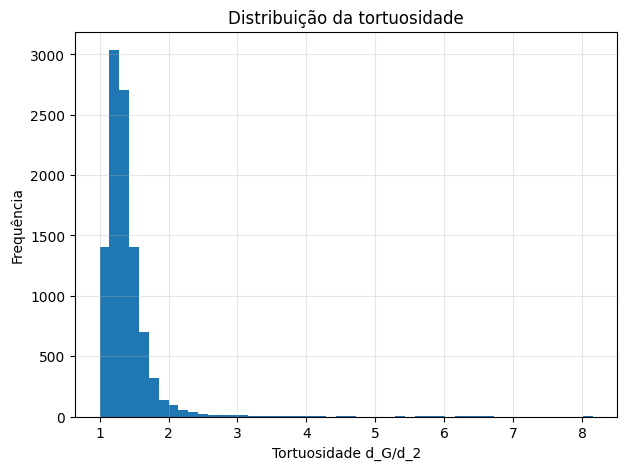

Figura salva em: c:\Users\caio24010\Documents\Gits\nao-e-so-reta\temp_codes_ruas\figures\tortuosidade_hist.png


In [10]:
tort_fig_path = FIGURES_DIR / "tortuosidade_hist.png"
fig, ax = sm.plot_tortuosity_hist(
    results,
    bins=50,
    filepath=tort_fig_path,
)
plt.show()
print("Figura salva em:", tort_fig_path)

## 9. Busca numérica do melhor $p$

Agora avaliamos uma grade de valores de $p$ entre 1 e 10. Esta etapa não recalcula menores caminhos; ela reaproveita as coordenadas dos pares e a coluna `d_graph_m` já calculada.

Por padrão, usamos passo `0.01`:

$p = 1.00, 1.01, 1.02, \ldots, 5.00.$

In [11]:
P_GRID = sm.p_grid(1.0, 5.0, 0.01)

grid_results = sm.evaluate_p_grid(
    results,
    P_GRID,
)

grid_results_path = RESULTS_DIR / "p_grid_results.csv"
sm.save_dataframe(grid_results, grid_results_path)

best_by_mape = sm.best_p_by(grid_results, criterion="MAPE_percent")
best_by_mae = sm.best_p_by(grid_results, criterion="MAE_m")

print("Melhor p por MAPE:")
display(best_by_mape.to_frame().T)

print("Melhor p por MAE:")
display(best_by_mae.to_frame().T)

Melhor p por MAPE:


,p,n,MAE_m,MAPE_percent,RMSE_m,bias_m
3,1.03,10000.0,590.7436,13.9342,816.8211,-293.9717


Melhor p por MAE:


,p,n,MAE_m,MAPE_percent,RMSE_m,bias_m
3,1.03,10000.0,590.7436,13.9342,816.8211,-293.9717


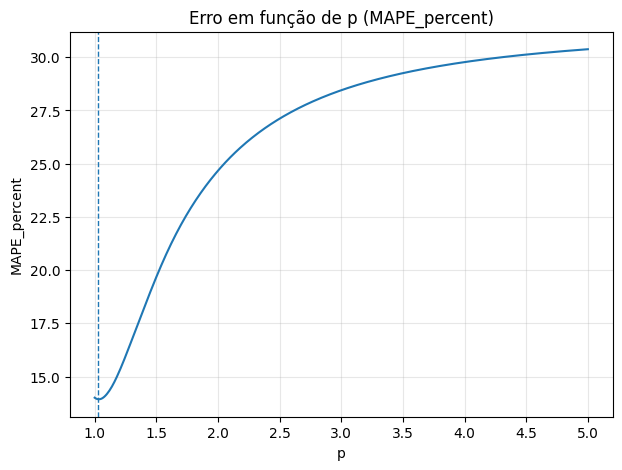

Figura salva em: c:\Users\caio24010\Documents\Gits\nao-e-so-reta\temp_codes_ruas\figures\mape_por_p.png


In [12]:
error_p_fig_path = FIGURES_DIR / "mape_por_p.png"
fig, ax = sm.plot_error_by_p(
    grid_results,
    criterion="MAPE_percent",
    filepath=error_p_fig_path,
)
plt.show()
print("Figura salva em:", error_p_fig_path)

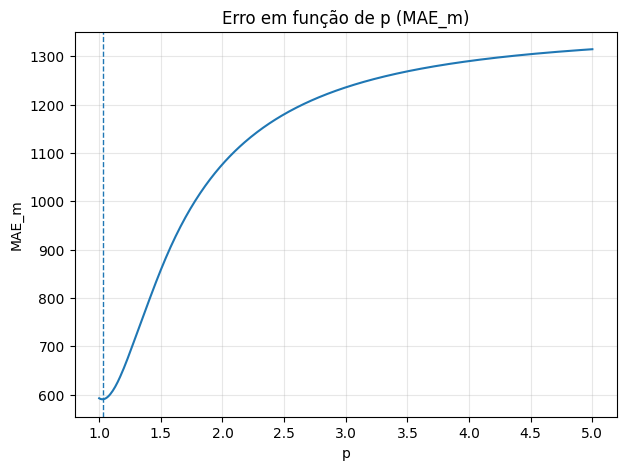

Figura salva em: c:\Users\caio24010\Documents\Gits\nao-e-so-reta\temp_codes_ruas\figures\mae_por_p.png


In [13]:
mae_p_fig_path = FIGURES_DIR / "mae_por_p.png"
fig, ax = sm.plot_error_by_p(
    grid_results,
    criterion="MAE_m",
    filepath=mae_p_fig_path,
)
plt.show()
print("Figura salva em:", mae_p_fig_path)

## 10. Gráficos de dispersão

Cada gráfico compara uma distância plana com a distância intrínseca no grafo. A linha tracejada é a identidade $y=x$. Pontos acima da linha indicam que a distância no grafo é maior que a métrica plana, o que é esperado para $d_2$ quando os caminhos do grafo são curvas poligonais no plano.

Plotando d_L2_m vs d_G para 10000 pares de vértices...


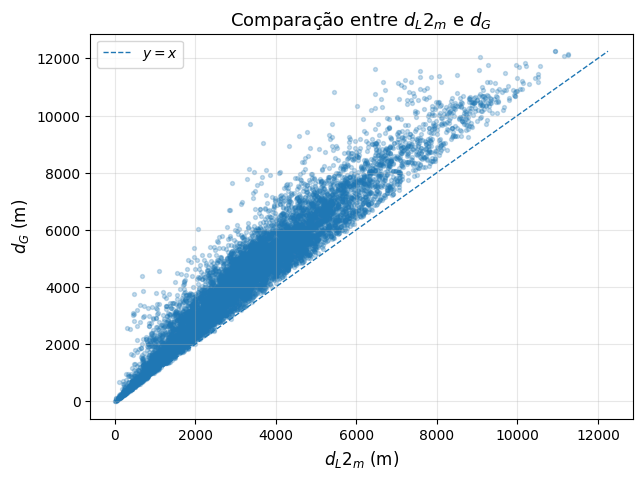

Figura salva em: c:\Users\caio24010\Documents\Gits\nao-e-so-reta\temp_codes_ruas\figures\scatter_L2_vs_dG.png


In [14]:
scatter_l2_path = FIGURES_DIR / "scatter_L2_vs_dG.png"
fig, ax = sm.plot_metric_scatter(
    results,
    sm.metric_column_from_p(2.0),
    filepath=scatter_l2_path,
)
plt.show()
print("Figura salva em:", scatter_l2_path)

Plotando d_L1_54_m vs d_G para 10000 pares de vértices...


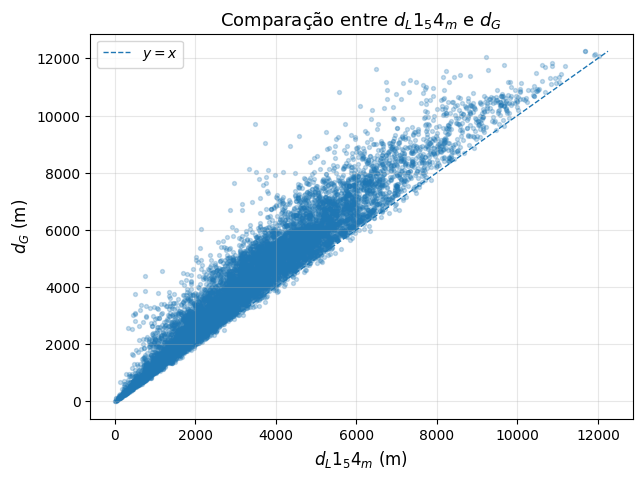

Figura salva em: c:\Users\caio24010\Documents\Gits\nao-e-so-reta\temp_codes_ruas\figures\scatter_L1_54_vs_dG.png


In [15]:
scatter_l154_path = FIGURES_DIR / "scatter_L1_54_vs_dG.png"
fig, ax = sm.plot_metric_scatter(
    results,
    sm.metric_column_from_p(1.54),
    filepath=scatter_l154_path,
)
plt.show()
print("Figura salva em:", scatter_l154_path)

Plotando d_L1_03_m vs d_G para 10000 pares de vértices...


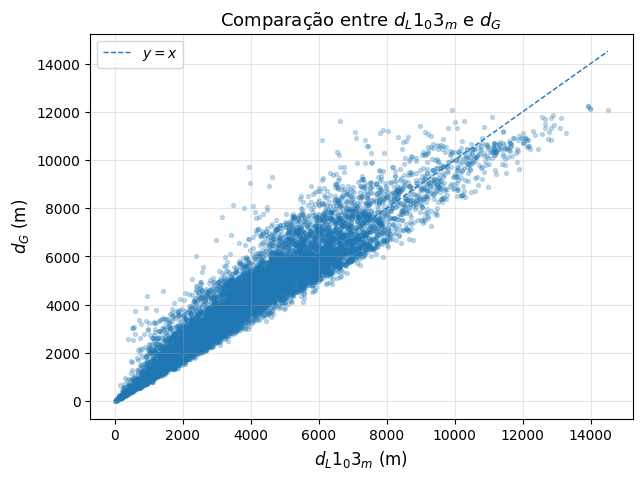

Melhor p por MAPE: 1.03
Figura salva em: c:\Users\caio24010\Documents\Gits\nao-e-so-reta\temp_codes_ruas\figures\scatter_best_p_vs_dG.png


In [16]:
# Adiciona coluna para o melhor p por MAPE, se ele não estiver entre os p fixos.
best_p = float(best_by_mape["p"])
best_col = sm.metric_column_from_p(best_p)

if best_col not in results.columns:
    results_best = sm.add_lp_columns(results, p_values=[best_p])
else:
    results_best = results

scatter_best_path = FIGURES_DIR / "scatter_best_p_vs_dG.png"
fig, ax = sm.plot_metric_scatter(
    results_best,
    best_col,
    filepath=scatter_best_path,
)
plt.show()
print(f"Melhor p por MAPE: {best_p:.2f}")
print("Figura salva em:", scatter_best_path)

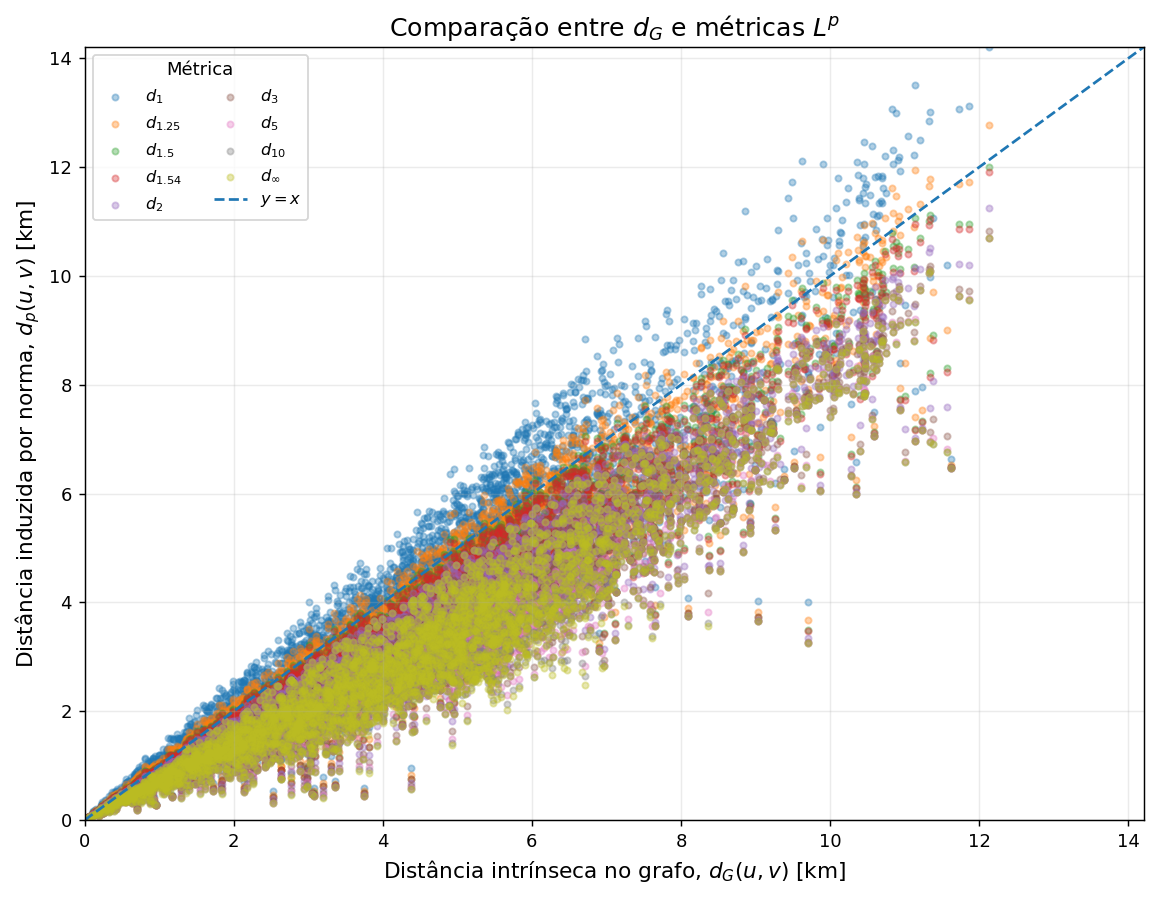

In [17]:
# Métricas que você quer comparar contra d_G.
metric_specs = [
    (sm.metric_column_from_p(1.0), r"$d_1$"),
    (sm.metric_column_from_p(1.25), r"$d_{1.25}$"),
    (sm.metric_column_from_p(1.5), r"$d_{1.5}$"),
    (sm.metric_column_from_p(1.54), r"$d_{1.54}$"),
    (sm.metric_column_from_p(2.0), r"$d_2$"),
    (sm.metric_column_from_p(3.0), r"$d_3$"),
    (sm.metric_column_from_p(5.0), r"$d_5$"),
    (sm.metric_column_from_p(10.0), r"$d_{10}$"),
    (sm.metric_column_from_p(math.inf), r"$d_\infty$"),
]

# Remove métricas que eventualmente não estejam no DataFrame.
metric_specs = [(col, label) for col, label in metric_specs if col in results.columns]

# Opcional: amostra pontos para o gráfico não ficar visualmente saturado.
# O cálculo estatístico continua usando todos os 10.000 pares.
plot_df = results.copy()

if len(plot_df) > 4000:
    plot_df = plot_df.sample(4000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 7), dpi=130)

x = plot_df["d_graph_m"] / 1000  # km

for col, label in metric_specs:
    y = plot_df[col] / 1000  # km
    ax.scatter(
        x,
        y,
        s=12,
        alpha=0.35,
        label=label,
    )

# Linha de referência y = x.
lim_max = max(
    plot_df["d_graph_m"].max(),
    max(plot_df[col].max() for col, _ in metric_specs),
) / 1000

ax.plot(
    [0, lim_max],
    [0, lim_max],
    linestyle="--",
    linewidth=1.5,
    label=r"$y=x$",
)

ax.set_xlim(0, lim_max)
ax.set_ylim(0, lim_max)

ax.set_xlabel(r"Distância intrínseca no grafo, $d_G(u,v)$ [km]", fontsize=12)
ax.set_ylabel(r"Distância induzida por norma, $d_p(u,v)$ [km]", fontsize=12)
ax.set_title(r"Comparação entre $d_G$ e métricas $L^p$", fontsize=14)

ax.grid(True, alpha=0.25)
ax.legend(title=r"Métrica", fontsize=9, title_fontsize=10, ncol=2)

plt.tight_layout()
plt.show()

Interpretação matemática inicial

Alguns pontos para usar na redação do artigo:

1. A distância euclidiana \(d_2\) entre dois vértices é um limite inferior natural para a distância no grafo quando as arestas do grafo representam segmentos ou curvas no plano com comprimento físico. Intuitivamente, qualquer caminho pela rede é um caminho admissível no plano, e o segmento reto é o menor caminho euclidiano.

2. A tortuosidade \(d_G/d_2\) mede o excesso imposto pela malha viária: quão mais longo é o deslocamento na rede em relação à separação euclidiana.

3. As métricas \(L^1\), \(L^p\) e \(L^\infty\) dependem da orientação dos eixos. Em uma malha urbana com direções predominantes, certos valores de \(p\) podem se ajustar melhor à geometria empírica do grafo.

4. Como a comparação aqui é direta, sem calibração multiplicativa, a métrica vencedora é aquela cuja escala e geometria bruta mais se aproximam de \(d_G\) para a amostra escolhida.

5. O valor ótimo de \(p\) deve ser interpretado empiricamente: ele não prova que a cidade “é” um espaço \(L^p\), mas indica qual norma da família \(L^p\) minimiza o erro escolhido sob a amostra e o recorte espacial utilizados.

## Referências práticas usadas no notebook

- OSMnx: biblioteca para baixar, modelar, projetar, analisar e visualizar redes urbanas a partir do OpenStreetMap.
- NetworkX: biblioteca usada para os algoritmos de menor caminho, incluindo Dijkstra em grafos ponderados.
- Ciclo Básico Unicamp: endereço oficial na Rua Sérgio Buarque de Holanda, nº 290.
- Terminal Barão Geraldo – Lázaro de Campos Faria: terminal em Barão Geraldo, Campinas.